**Connecting to Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installing Required Packages**

In [2]:
!pip install -U segmentation-models-pytorch
!pip install -U albumentations
import os
import glob
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# segmentation model library
import segmentation_models_pytorch as smp

# augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# pytorch utils
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00
PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [3]:
# === SET THIS TO YOUR NEW TRAINING DATASET ZIP (the ~2000 image dataset) ===
# After extraction this zip must contain ONE top-level folder with two
# subfolders inside it: "images" and "labels". Both "images" and "labels"
# must contain the SAME 6 class subfolders:
#   Debris Cover, Terrain Shadow, Snow Cover, Moraine Dammed, Cloud Cover, Varying Turbidity
# Update the path below to match the exact zip filename in your Google Drive.
ZIP_PATH = "/content/drive/MyDrive/GLOFEagles Challenge Validation Dataset-20260618T152553Z-3-001.zip"


In [4]:
import zipfile
import os

EXTRACT_DIR = "/content/glof_validation"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction Complete")

Extraction Complete


# (duplicate extraction cell removed — extraction already happens in the cell above)


In [5]:
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    print(root)

/content/glof_validation
/content/glof_validation/GLOFEagles Challenge Validation Dataset
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Cloud Cover
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Terrain Shadow
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Moraine Dammed
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Snow Cover
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Debris Cover
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Varying Turbidity
/content/glof_validation/GLOFEagles Challenge Validation Dataset/labels
/content/glof_validation/GLOFEagles Challenge Validation Dataset/labels/Cloud Cover
/content/glof_validation/GLOFEagles Challenge Validation Dataset/labels/Terrain Shadow
/content/glof_validation/GLOFEagles Challenge Validation Dataset/labels/Moraine

In [6]:
import os

for item in os.listdir(EXTRACT_DIR):
    print(item)

GLOFEagles Challenge Validation Dataset


In [7]:
# Root folder name exactly as it appears after extraction
# (check the printout from the two cells above and adjust if it differs)
DATASET_FOLDER_NAME = "GLOFEagles Challenge Validation Dataset"

IMAGES_DIR = os.path.join(EXTRACT_DIR, DATASET_FOLDER_NAME, "images")
LABELS_DIR = os.path.join(EXTRACT_DIR, DATASET_FOLDER_NAME, "labels")

print("Images dir exists:", os.path.exists(IMAGES_DIR), "->", IMAGES_DIR)
print("Labels dir exists:", os.path.exists(LABELS_DIR), "->", LABELS_DIR)


Images dir exists: True -> /content/glof_validation/GLOFEagles Challenge Validation Dataset/images
Labels dir exists: True -> /content/glof_validation/GLOFEagles Challenge Validation Dataset/labels


In [8]:
import glob

all_image_paths = sorted(
    glob.glob(
        os.path.join(IMAGES_DIR, "**", "*.png"),
        recursive=True
    )
)

print("Total Images Found:", len(all_image_paths))


Total Images Found: 2220


**Defining Paths**

In [9]:
# === TRAINING / OUTPUT CONFIG ===
IMG_BASE        = IMAGES_DIR    # raw images, 6 class subfolders, ~2000 images total
GT_BASE         = LABELS_DIR    # masks, same 6 class subfolders + same filenames as IMG_BASE

MODEL_SAVE_PATH = "/content/drive/My Drive/final_modal/glacierlake_model.pth"
ALL_IMAGES_PATH = IMAGES_DIR    # images to batch-predict on after training

# NEW output folder for the predicted masks (separate from the training labels)
OUTPUT_DIR = "/content/drive/MyDrive/GLOF_2000_Predicted_Masks"

IMG_SIZE   = 512
BATCH_SIZE = 4
EPOCHS     = 100
LR         = 1e-3
THRESHOLD  = 0.32
TEST_SIZE  = 0.30   # 70% train / 30% val split

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [10]:
print("IMG_BASE exists:", os.path.exists(IMG_BASE))
print("GT_BASE  exists:", os.path.exists(GT_BASE))


IMG_BASE exists: True
GT_BASE  exists: True


**Creating image-mask pair**

In [11]:
pairs = []

for cls in sorted(os.listdir(IMG_BASE)):
    img_folder  = os.path.join(IMG_BASE, cls)
    mask_folder = os.path.join(GT_BASE, cls)
    if not os.path.isdir(img_folder):
        continue
    for fname in os.listdir(img_folder):
        img_path  = os.path.join(img_folder, fname)
        mask_path = os.path.join(mask_folder, fname)
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path, cls))

class_counts = Counter(cls for _, _, cls in pairs)
print(f"\nTotal labeled pairs: {len(pairs)}")
print("\nPer-class distribution:")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls:20s}: {count} images")


Total labeled pairs: 2220

Per-class distribution:
  Cloud Cover         : 12 images
  Debris Cover        : 234 images
  Moraine Dammed      : 835 images
  Snow Cover          : 834 images
  Terrain Shadow      : 239 images
  Varying Turbidity   : 66 images


**Defining Training and Val Set**

In [12]:
pair_data    = [(img, mask) for img, mask, _ in pairs]
pair_classes = [cls for _, _, cls in pairs]

train_pairs, val_pairs, train_classes, val_classes = train_test_split(
    pair_data,
    pair_classes,
    test_size=TEST_SIZE,     # 0.30 -> 70% train / 30% val
    random_state=42,
    stratify=pair_classes
)

print(f"Train set: {len(train_pairs)} images")
print(f"Val   set: {len(val_pairs)}  images")


Train set: 1554 images
Val   set: 666  images


**Data Augmentation**

In [13]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    #Geometric
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.10, scale_limit=0.15,
        rotate_limit=30, border_mode=0, p=0.6
    ),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),

    #Photometric
    A.RandomBrightnessContrast(
        brightness_limit=0.40, contrast_limit=0.40, p=0.7
    ),
    A.HueSaturationValue(
        hue_shift_limit=20, sat_shift_limit=40, val_shift_limit=30, p=0.5
    ),
    A.CLAHE(clip_limit=6.0, tile_grid_size=(8, 8), p=0.5),
    A.GaussNoise(var_limit=(10.0, 80.0), p=0.4),
    A.RandomGamma(gamma_limit=(60, 140), p=0.4),
    A.RandomShadow(
        shadow_roi=(0, 0, 1, 1),
        num_shadows_lower=1,
        num_shadows_upper=3,
        shadow_dimension=5,
        p=0.4
    ),

    # Occlusion
    A.CoarseDropout(
        max_holes=12, max_height=32, max_width=32,
        min_holes=4,  min_height=8,  min_width=8,
        fill_value=0, p=0.4
    ),

    # Normalize
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [14]:
class LakeDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = cv2.imread(img_path)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out["image"]
            mask = out["mask"]

        return img.float(), mask.float().unsqueeze(0)

In [15]:
train_ds = LakeDataset(train_pairs, transform=train_transform)
val_ds   = LakeDataset(val_pairs,   transform=val_transform)

class_freq   = Counter(train_classes)
debris_keywords = ["debris", "Debris", "covered", "Covered"]

def get_weight(cls):
    if any(k in cls for k in debris_keywords):
        return 3.0 / class_freq[cls]   # 3× oversampling for debris class
    return 1.0 / class_freq[cls]

sample_weights = torch.tensor([get_weight(c) for c in train_classes], dtype=torch.float)
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=2,
                          shuffle=False, num_workers=2, pin_memory=True)

imgs, masks = next(iter(train_loader))
print(f"Batch check — img: {imgs.shape} {imgs.dtype}  "
      f"mask: {masks.shape} {masks.dtype}")
print(f"Mask pixel range: [{masks.min():.0f}, {masks.max():.0f}]  "
      f"Lake pixels in batch: {masks.sum():.0f}")

Batch check — img: torch.Size([4, 3, 512, 512]) torch.float32  mask: torch.Size([4, 1, 512, 512]) torch.float32
Mask pixel range: [0, 1]  Lake pixels in batch: 8400


In [16]:
def compute_ndwi_rgb(img_rgb):
    green = img_rgb[:, :, 1].astype(np.float32)
    blue  = img_rgb[:, :, 2].astype(np.float32)
    ndwi  = (green - blue) / (green + blue + 1e-6)
    return np.clip((ndwi + 1) / 2, 0, 1)

def make_4channel(img_rgb):
    ndwi = compute_ndwi_rgb(img_rgb)
    return np.dstack([img_rgb, (ndwi * 255).astype(np.uint8)])


**Model Architecture: U-Net++ with EfficientNet Encoder**

In [17]:
model = smp.UnetPlusPlus(
    encoder_name    = "efficientnet-b3",
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
    activation      = None
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Total trainable parameters: 13,624,793


**Lake Function for Lake Segmentation**

In [18]:
dice_loss_fn  = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
focal_loss_fn = smp.losses.FocalLoss(smp.losses.BINARY_MODE)

def boundary_loss(pred_logits, target, weight=0.2):
    """Penalises errors near lake boundaries more heavily."""
    pred    = torch.sigmoid(pred_logits)
    kernel  = torch.ones(1, 1, 5, 5, device=target.device) / 25.0
    dilated = F.conv2d(target, kernel, padding=2).clamp(0, 1)
    boundary_region = dilated - target # ring around lake edge
    bce      = F.binary_cross_entropy(pred, target, reduction='none')
    weighted = bce * (1.0 + weight * boundary_region * 10)
    return weighted.mean()

def combined_loss(pred, target, alpha=0.4):
    """40% Focal + 40% Dice + 20% Boundary  (single, authoritative definition)"""
    return (alpha * focal_loss_fn(pred, target)
          + 0.4   * dice_loss_fn(pred, target)
          + 0.2   * boundary_loss(pred, target))

**Evaluation Metrics: IoU and Dice Score**

In [19]:
def compute_iou(pred_logits, target, thr=THRESHOLD):
    pred  = (torch.sigmoid(pred_logits) > thr).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - inter
    return ((inter + 1e-6) / (union + 1e-6)).mean().item()

def compute_dice(pred_logits, target, thr=THRESHOLD):
    pred  = (torch.sigmoid(pred_logits) > thr).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * inter + 1e-6) / (union + 1e-6)).mean().item()

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)


**Model Training**

In [21]:
history       = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # Validate
    model.eval()
    v_loss = v_iou = v_dice = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds  = model(imgs)
            v_loss += combined_loss(preds, masks).item()
            v_iou  += compute_iou(preds, masks)
            v_dice += compute_dice(preds, masks)

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(val_loader)
    avg_i = v_iou  / len(val_loader)
    avg_d = v_dice / len(val_loader)

    history["train_loss"].append(avg_t)
    history["val_loss"].append(avg_v)
    history["val_iou"].append(avg_i)
    history["val_dice"].append(avg_d)

    scheduler.step()

    # Save best checkpoint
    saved = ""
    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved = "SAVED"

    if epoch % 10 == 0 or epoch == 1 or saved:
        print(f"Epoch {epoch:3d}/{EPOCHS} │ "
              f"train={avg_t:.4f}  val={avg_v:.4f}  "
              f"IoU={avg_i:.3f}  Dice={avg_d:.3f}{saved}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Epoch   1/100 │ train=0.3674  val=0.2636  IoU=0.316  Dice=0.421SAVED
Epoch   2/100 │ train=0.2990  val=0.2468  IoU=0.363  Dice=0.470SAVED
Epoch   4/100 │ train=0.2694  val=0.2070  IoU=0.449  Dice=0.537SAVED
Epoch   5/100 │ train=0.2736  val=0.2009  IoU=0.444  Dice=0.554SAVED
Epoch   6/100 │ train=0.2552  val=0.1905  IoU=0.474  Dice=0.574SAVED
Epoch   7/100 │ train=0.2538  val=0.1863  IoU=0.503  Dice=0.597SAVED
Epoch  10/100 │ train=0.2577  val=0.1580  IoU=0.557  Dice=0.646SAVED
Epoch  20/100 │ train=0.2348  val=0.2001  IoU=0.477  Dice=0.569
Epoch  25/100 │ train=0.2223  val=0.1535  IoU=0.565  Dice=0.651SAVED
Epoch  30/100 │ train=0.2308  val=0.1526  IoU=0.561  Dice=0.651SAVED
Epoch  31/100 │ train=0.2205  val=0.1488  IoU=0.582  Dice=0.662SAVED
Epoch  32/100 │ train=0.2201  val=0.1435  IoU=0.579  Dice=0.662SAVED
Epoch  34/100 │ train=0.1923  val=0.1354  IoU=0.602  Dice=0.681SAVED
Epoch  40/100 │ train=0.1876  val=0.1532  IoU=0.561  Dice=0.632
Epoch  47/100 │ train=0.1829  val=0.1294  Io

KeyboardInterrupt: 

**Training Curve**

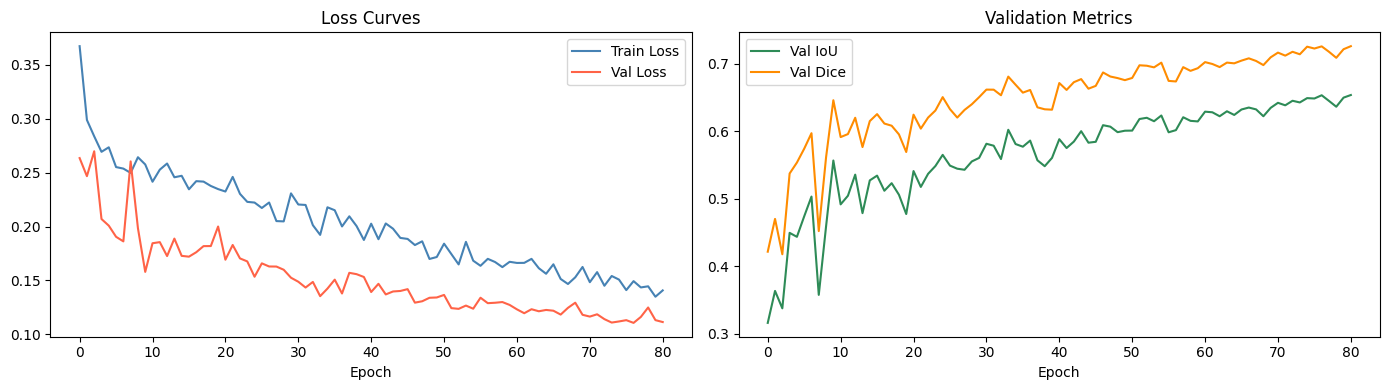

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_iou"],  label="Val IoU",  color="seagreen")
axes[1].plot(history["val_dice"], label="Val Dice", color="darkorange")
axes[1].set_title("Validation Metrics")
axes[1].legend()
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves.png", dpi=150)
plt.show()



In [23]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.to(device)
model.eval()
print("Loaded trained weights successfully")


Loaded trained weights successfully


**Lake Segmentation**

In [24]:
def predict_lake_mask_tta(image_path, threshold=0.50, min_area=50):

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]

    scales = [384, 512, 640]
    probs_accum = np.zeros((orig_h, orig_w), dtype=np.float32)

    tta_images = [
        img_rgb,
        np.fliplr(img_rgb),
        np.flipud(img_rgb),
        np.rot90(img_rgb, 1),
        np.rot90(img_rgb, 2),
        np.rot90(img_rgb, 3),
    ]

    model.eval()
    with torch.no_grad():
        for scale in scales:
            scale_probs = np.zeros((orig_h, orig_w), dtype=np.float32)

            preprocess = A.Compose([
                A.Resize(scale, scale),
                A.Normalize(mean=(0.485, 0.456, 0.406),
                            std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

            for i, aug_img in enumerate(tta_images):
                x = preprocess(image=aug_img.copy())["image"].unsqueeze(0).float().to(device)
                prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()

                if i == 1: prob = np.fliplr(prob)
                elif i == 2: prob = np.flipud(prob)
                elif i == 3: prob = np.rot90(prob, -1)
                elif i == 4: prob = np.rot90(prob, -2)
                elif i == 5: prob = np.rot90(prob, -3)

                prob = cv2.resize(prob, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
                scale_probs += prob

            probs_accum += scale_probs / len(tta_images)

    prob_map = probs_accum / len(scales)

    # Threshold
    binary = (prob_map > threshold).astype(np.uint8)

    # Morphological cleanup
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    filtered = np.zeros_like(binary)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            filtered[labels == lbl] = 1

    return img_rgb, prob_map, filtered

**Visualization of Model Prediction**

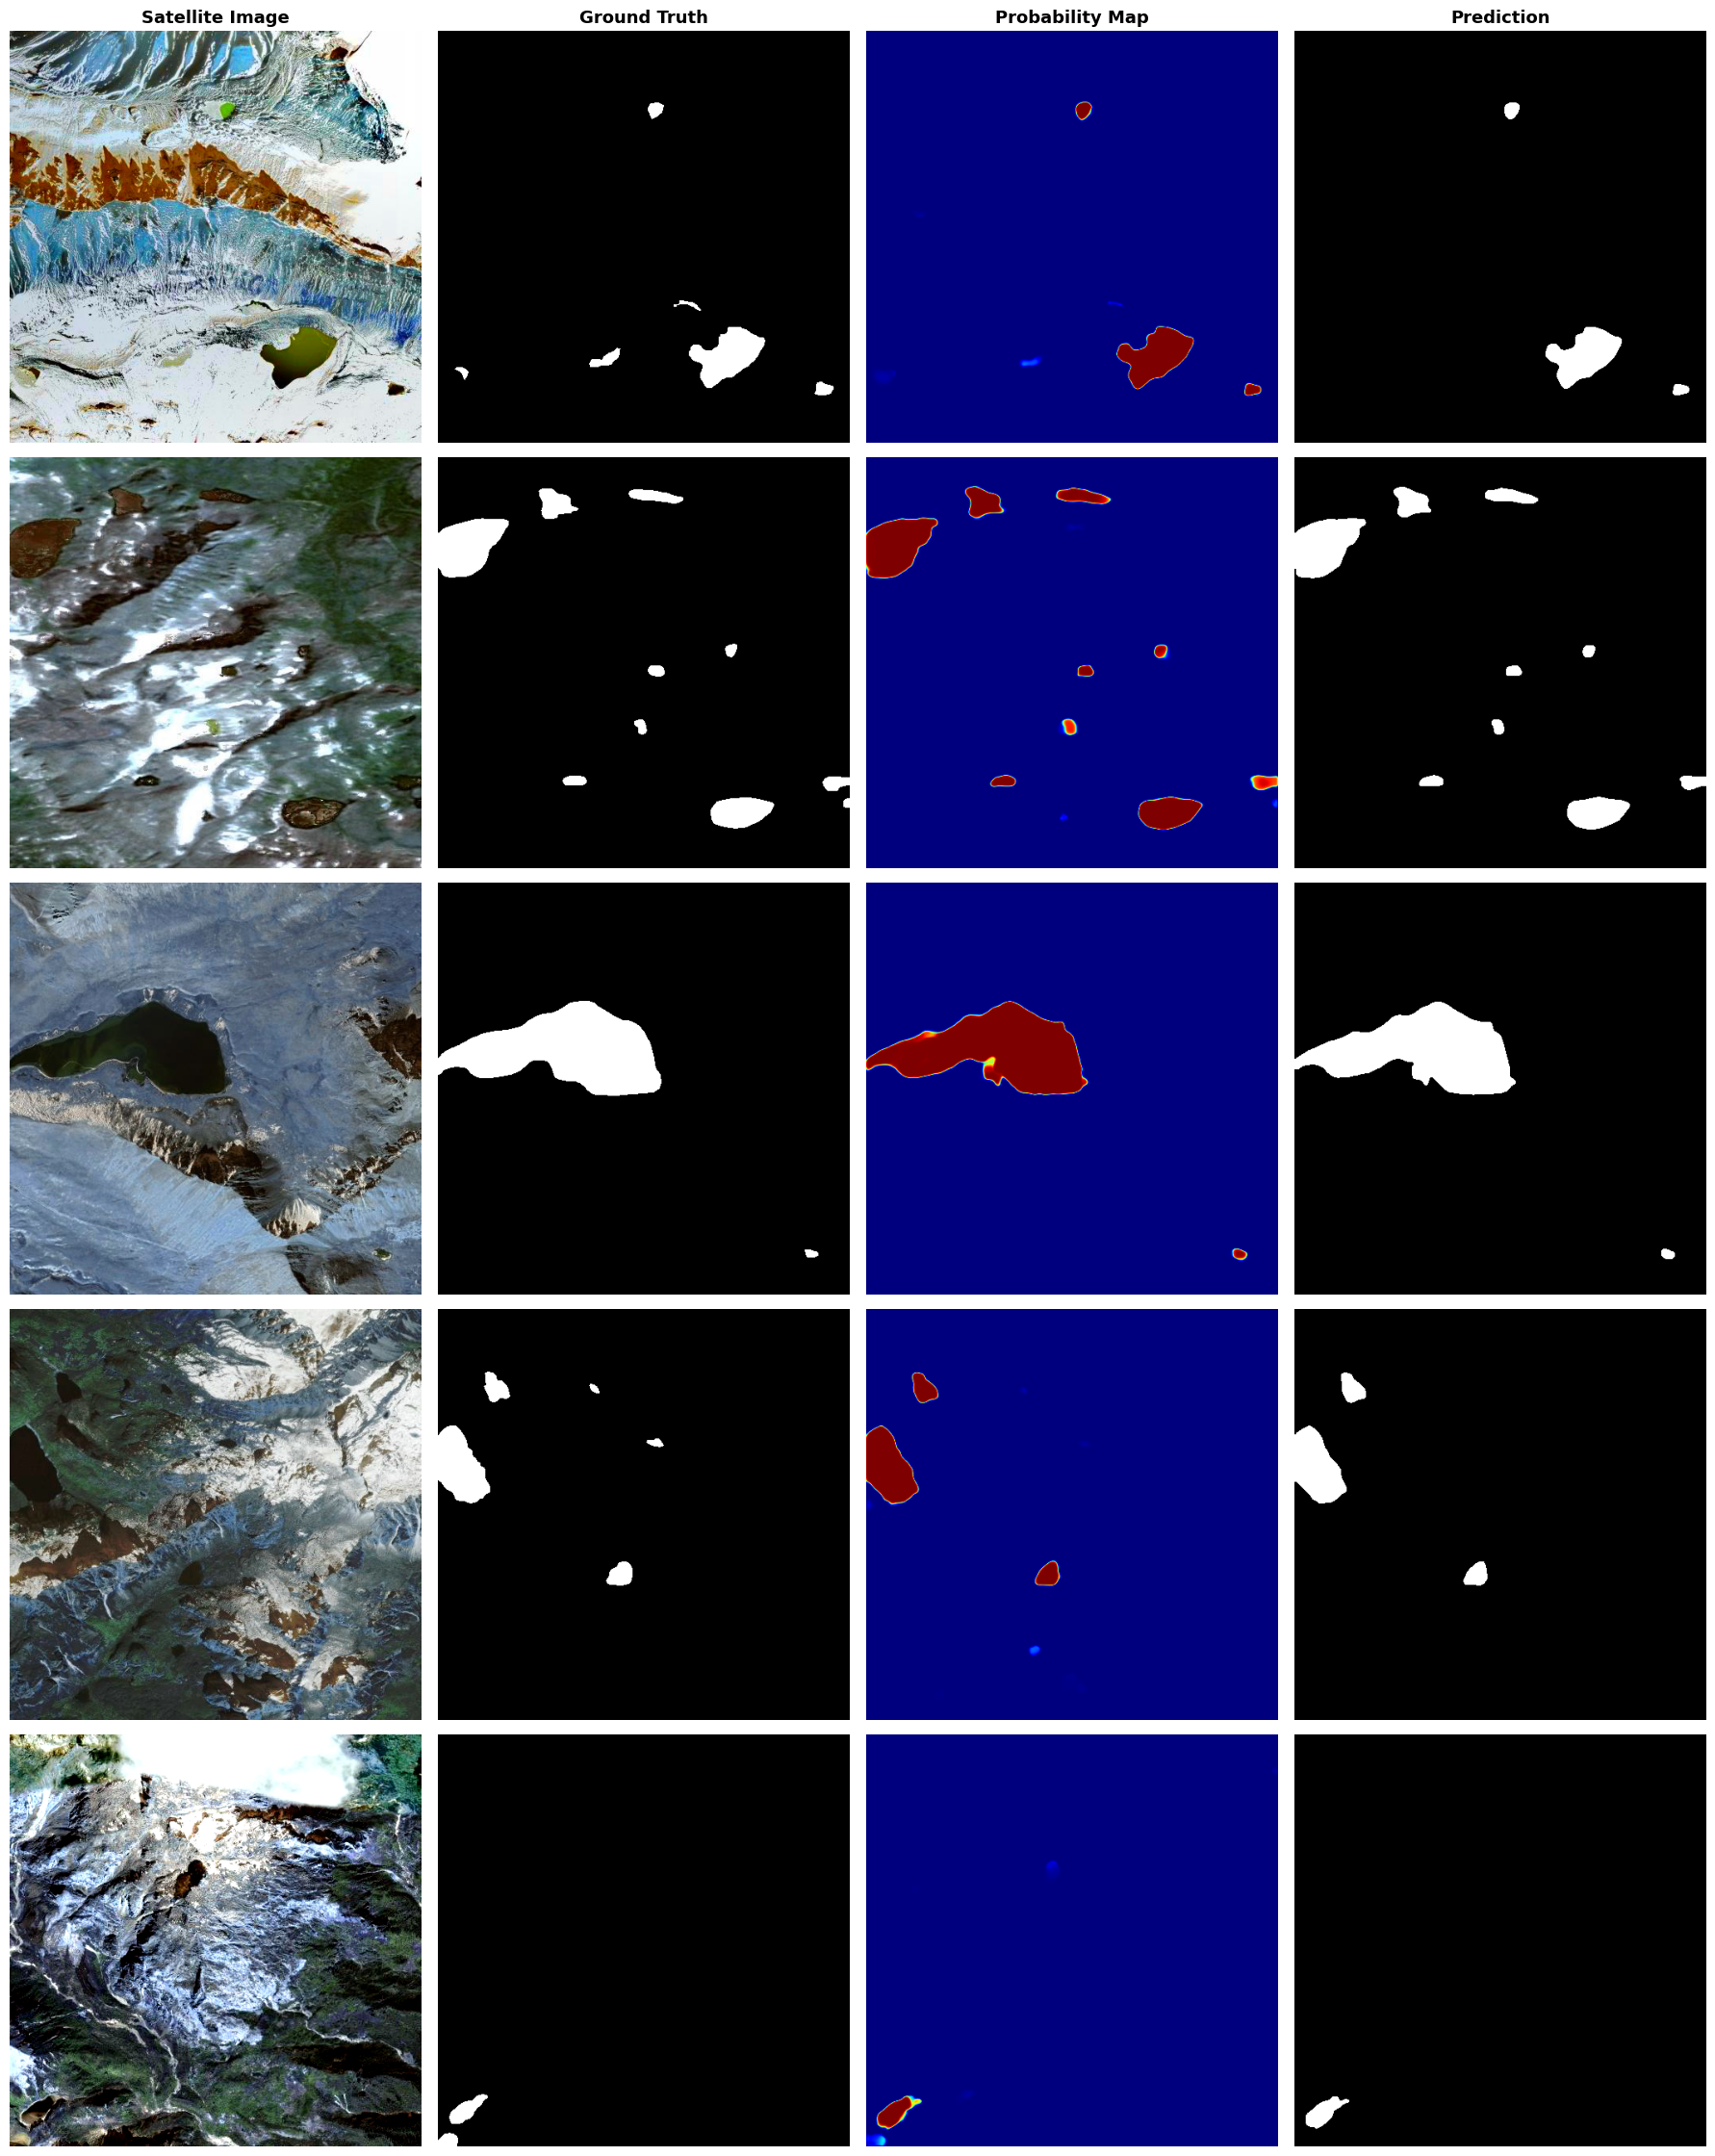

In [25]:
n_show = min(5, len(val_pairs))
fig, axes = plt.subplots(n_show, 4, figsize=(18, 4.5 * n_show))
if n_show == 1:
    axes = [axes]

col_titles = ["Satellite Image", "Ground Truth", "Probability Map", "Prediction"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold")

for i, (img_path, mask_path) in enumerate(val_pairs[:n_show]):
    img_rgb, prob_map, pred_mask = predict_lake_mask_tta(img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    axes[i][0].imshow(img_rgb)
    axes[i][1].imshow(gt_mask,   cmap="gray")
    axes[i][2].imshow(prob_map,  cmap="jet", vmin=0, vmax=1)
    axes[i][3].imshow(pred_mask, cmap="gray")

    for ax in axes[i]:
        ax.axis("off")

    pred_bin = (pred_mask > 127).astype(np.uint8)
    gt_bin   = (gt_mask   > 127).astype(np.uint8)
    inter    = np.logical_and(pred_bin, gt_bin).sum()
    union    = np.logical_or( pred_bin, gt_bin).sum()
    iou      = inter / (union + 1e-6)
    axes[i][0].set_ylabel(f"IoU={iou:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/val_predictions.png", dpi=150)
plt.show()


**Testing one Image**

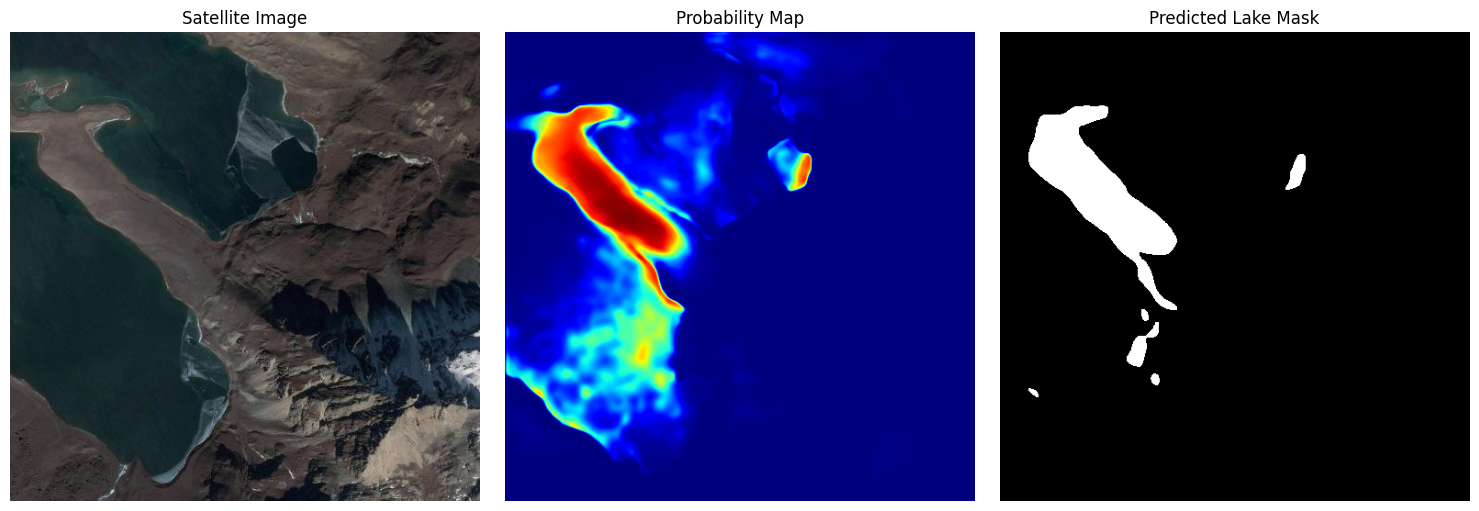

In [26]:
TEST_IMAGE = "/content/drive/My Drive/SNU/114.png"

img_rgb, prob_map, pred_mask = predict_lake_mask_tta(TEST_IMAGE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb);               axes[0].set_title("Satellite Image")
axes[1].imshow(prob_map, cmap="jet");  axes[1].set_title("Probability Map")
axes[2].imshow(pred_mask, cmap="gray");axes[2].set_title("Predicted Lake Mask")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

In [27]:
#THRESHOLD SWEEP
print("finding optimal threshold on val set")

best_iou_val, BEST_THRESHOLD = 0.0, THRESHOLD

for thr in [0.10, 0.15, 0.18, 0.20, 0.25, 0.30, 0.32, 0.35, 0.40, 0.45, 0.50]:
    model.eval()
    iou_sum = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            iou_sum += compute_iou(model(imgs), masks, thr=thr)
    avg_iou = iou_sum / len(val_loader)
    marker  = "  ← best so far" if avg_iou > best_iou_val else ""
    print(f"  threshold = {thr:.2f}  |  Val IoU = {avg_iou:.4f}{marker}")
    if avg_iou > best_iou_val:
        best_iou_val, BEST_THRESHOLD = avg_iou, thr

print(f"\nBest threshold = {BEST_THRESHOLD}  |  Best Val IoU = {best_iou_val:.4f}")

finding optimal threshold on val set
  threshold = 0.10  |  Val IoU = 0.6450  ← best so far
  threshold = 0.15  |  Val IoU = 0.6496  ← best so far
  threshold = 0.18  |  Val IoU = 0.6507  ← best so far
  threshold = 0.20  |  Val IoU = 0.6513  ← best so far
  threshold = 0.25  |  Val IoU = 0.6523  ← best so far
  threshold = 0.30  |  Val IoU = 0.6532  ← best so far
  threshold = 0.32  |  Val IoU = 0.6535  ← best so far
  threshold = 0.35  |  Val IoU = 0.6539  ← best so far
  threshold = 0.40  |  Val IoU = 0.6543  ← best so far
  threshold = 0.45  |  Val IoU = 0.6545  ← best so far
  threshold = 0.50  |  Val IoU = 0.6545  ← best so far

Best threshold = 0.5  |  Best Val IoU = 0.6545


**Model Evaluation Metrics**

In [28]:
# FINAL FULL METRICS
print(f"FINAL METRICS  (threshold = {BEST_THRESHOLD})")

def compute_all_metrics(model, loader, threshold, device="cpu"):
    model.eval()
    TP = FP = FN = TN = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            probs  = torch.sigmoid(model(imgs))
            preds  = (probs > threshold).float()

            preds_f = preds.view(-1)
            masks_f = masks.view(-1)

            TP += ((preds_f == 1) & (masks_f == 1)).sum().item()
            FP += ((preds_f == 1) & (masks_f == 0)).sum().item()
            FN += ((preds_f == 0) & (masks_f == 1)).sum().item()
            TN += ((preds_f == 0) & (masks_f == 0)).sum().item()

    iou         = TP / (TP + FP + FN + 1e-6)
    precision   = TP / (TP + FP + 1e-6)
    recall      = TP / (TP + FN + 1e-6)
    f1          = 2 * precision * recall / (precision + recall + 1e-6)
    dice        = 2 * TP / (2 * TP + FP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)

    total = TP + FP + FN + TN
    po    = (TP + TN) / total
    pe    = ((TP + FP) * (TP + FN) + (FN + TN) * (FP + TN)) / (total ** 2 + 1e-6)
    kappa = (po - pe) / (1 - pe + 1e-6)

    print(f"  IoU         : {iou:.4f}")
    print(f"  Precision   : {precision:.4f}")
    print(f"  Recall      : {recall:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print(f"  Dice        : {dice:.4f}")
    print(f"  Specificity : {specificity:.4f}")
    print(f"  Kappa       : {kappa:.4f}")
    print(f"\n  TP={TP:,}  FP={FP:,}  FN={FN:,}  TN={TN:,}")

    return dict(iou=iou, precision=precision, recall=recall, f1=f1,
                dice=dice, specificity=specificity, kappa=kappa,
                TP=TP, FP=FP, FN=FN, TN=TN)

metrics = compute_all_metrics(model, val_loader,
                              threshold=BEST_THRESHOLD, device=device)

FINAL METRICS  (threshold = 0.5)
  IoU         : 0.6933
  Precision   : 0.8602
  Recall      : 0.7813
  F1 Score    : 0.8189
  Dice        : 0.8189
  Specificity : 0.9974
  Kappa       : 0.8154

  TP=2,704,849  FP=439,682  FN=756,950  TN=170,686,423


In [29]:
# SAVE MODEL WEIGHTS
SAVE_DIR = "/content/drive/MyDrive/final_final/FINAL"
os.makedirs(SAVE_DIR, exist_ok=True)

STATE_DICT_PATH = os.path.join(SAVE_DIR, "glacier_lake_model_final.pth")
torch.save(model.state_dict(), STATE_DICT_PATH)
print(f"State dict saved  → {STATE_DICT_PATH}")
checkpoint = {
    "model_state_dict"  : model.state_dict(),
    "best_threshold"    : BEST_THRESHOLD,
    "val_metrics"       : metrics,
    "model_architecture": "UnetPlusPlus-efficientnet-b3",
}
CKPT_PATH = os.path.join(SAVE_DIR, "glacier_lake_checkpoint.pth")
torch.save(checkpoint, CKPT_PATH)
print(f"Full checkpoint saved → {CKPT_PATH}")

State dict saved  → /content/drive/MyDrive/final_final/FINAL/glacier_lake_model_final.pth
Full checkpoint saved → /content/drive/MyDrive/final_final/FINAL/glacier_lake_checkpoint.pth


In [1]:
all_image_paths = sorted(
    glob.glob(
        os.path.join(ALL_IMAGES_PATH, "**", "*.png"),
        recursive=True
    )
)

print(f"Found {len(all_image_paths)} images to process...\n")

blank_count = 0

for img_path in all_image_paths:

    try:

        _, _, pred_mask = predict_lake_mask_tta(
            img_path,
            threshold=BEST_THRESHOLD
        )

        mask_out = (pred_mask > 0).astype(np.uint8) * 255

        # Preserve folder structure
        relative_path = os.path.relpath(
            img_path,
            ALL_IMAGES_PATH
        )

        save_path = os.path.join(
            OUTPUT_DIR,
            relative_path.replace(".png", "_mask.png")
        )

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        cv2.imwrite(save_path, mask_out)

        if mask_out.sum() == 0:
            blank_count += 1

    except Exception as e:
        print(f"FAILED: {img_path}")
        print(e)

total = len(all_image_paths)

print(f"\nDone.")
print(f"Images processed : {total}")
print(f"Blank masks      : {blank_count}")
print(f"Non-blank masks  : {total - blank_count}")

NameError: name 'glob' is not defined

In [ ]:
print("OUTPUT QUALITY CHECK — scanning saved masks")

black_images, all_masks = [], []

for fname in sorted(os.listdir(OUTPUT_DIR)):
    if not fname.endswith("_mask.png"):
        continue
    img = cv2.imread(os.path.join(OUTPUT_DIR, fname), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    all_masks.append(fname)
    if np.sum(img) == 0:
        black_images.append(fname)

total = len(all_masks)
print(f"\nTotal masks saved    : {total}")
print(f"With lake pixels     : {total - len(black_images)}")
print(f"Completely blank     : {len(black_images)}")
print(f"Blank %              : {100 * len(black_images) / max(total, 1):.1f}%")

if black_images:
    print(f"\n Blank masks (first 20):")
    for name in black_images[:20]:
        print(f"   {name}")
    if len(black_images) > 20:
        print(f"   ... and {len(black_images) - 20} more.")
else:
    print("\n No blank masks — all outputs contain lake predictions.")

ONLINE EXTERNAL IMAGE TESTING

In [ ]:
TEST_IMAGE = "/content/drive/My Drive/online_image/1.png"

img_rgb, prob_map, pred_mask = predict_lake_mask_tta(TEST_IMAGE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb);               axes[0].set_title("Satellite Image")
axes[1].imshow(prob_map, cmap="jet");  axes[1].set_title("Probability Map")
axes[2].imshow(pred_mask, cmap="gray");axes[2].set_title("Predicted Lake Mask")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()